# Task 2: Girvan-Newman Algorithm Partitioning

## Required Imports

In [ ]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import networkx as nx
import itertools

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Load Dataset and Construct MultiDiGraph with Features

In [ ]:
df_links = pd.read_csv("/content/drive/My Drive/ORF387_Project/heaberlin_dedeo_norm_network/links.csv")
print(df_links)

       Source  Target
0           0     117
1           0     491
2           0     603
3           0     773
4           0    1020
...       ...     ...
17230    1975    1038
17231    1975    1254
17232    1975    1381
17233    1975    1719
17234    1975    1765

[17235 rows x 2 columns]


In [ ]:
df_nodes = pd.read_csv("/content/drive/My Drive/ORF387_Project/heaberlin_dedeo_norm_network/nodes.csv", sep="\t")
print(df_nodes.head(1))

   Page ID                        Name            Creation Date   Type  \
0        0  In_popular_culture_content  2007-02-12 18:56:47 UTC  Essay   

   Louvain Community  Final In Degree  EC Estimate  \
0                  1                0     0.000163   

   Fraction of total pageviews (July 2015)  Number of Edits  Unique Editors  \
0                                 0.000205              399             171   

   Number of Talk Page Edits  Unique Talk Page Editors  Page Size  
0                        267                       267       1560  


In [ ]:
df_topics = pd.read_csv("/content/drive/My Drive/ORF387_Project/heaberlin_dedeo_norm_network/topics.csv", sep="\t")
print(df_topics.head(1))

   Page ID  Number of Words       Topic 1   Topic 2       Topic 3   Topic 4  \
0        0            959.0  1.710234e-19  0.076057  2.305177e-19  0.653648   

        Topic 5   Topic 6       Topic 7   Topic 8  ...      Topic 11  \
0  1.143827e-19  0.034452  1.117835e-19  0.235844  ...  1.289104e-19   

       Topic 12      Topic 13      Topic 14      Topic 15      Topic 16  \
0  1.473083e-19  1.676075e-19  1.812079e-19  1.077796e-19  1.215833e-19   

       Topic 17      Topic 18      Topic 19      Topic 20  
0  9.847681e-20  1.560968e-19  2.410273e-19  1.947174e-19  

[1 rows x 22 columns]


In [ ]:
df_all_node_features = df_nodes.merge(df_topics, on="Page ID", how="left")
print(df_all_node_features.columns)

Index(['Page ID', 'Name', 'Creation Date', 'Type', 'Louvain Community',
       'Final In Degree', 'EC Estimate',
       'Fraction of total pageviews (July 2015)', 'Number of Edits',
       'Unique Editors', 'Number of Talk Page Edits',
       'Unique Talk Page Editors', 'Page Size', 'Number of Words', 'Topic 1',
       'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5', 'Topic 6', 'Topic 7',
       'Topic 8', 'Topic 9', 'Topic 10', 'Topic 11', 'Topic 12', 'Topic 13',
       'Topic 14', 'Topic 15', 'Topic 16', 'Topic 17', 'Topic 18', 'Topic 19',
       'Topic 20'],
      dtype='object')


In [ ]:
# Consulted official NetworkX documentation at:
# https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html
# https://networkx.org/documentation/stable/reference/classes/multidigraph.html

G = nx.from_pandas_edgelist(df_links, source="Source", target="Target", create_using=nx.MultiDiGraph)
G.add_nodes_from((n, dict(d)) for n, d in df_all_node_features.iterrows())
id_to_name = df_nodes.set_index("Page ID")["Name"].to_dict()
id_to_comm = df_nodes.set_index("Page ID")["Louvain Community"].to_dict()
print(G)
print(G.nodes[0])

MultiDiGraph with 1976 nodes and 17235 edges
{'Page ID': 0, 'Name': 'In_popular_culture_content', 'Creation Date': '2007-02-12 18:56:47 UTC', 'Type': 'Essay', 'Louvain Community': 1, 'Final In Degree': 0, 'EC Estimate': 0.0001626162778894, 'Fraction of total pageviews (July 2015)': 0.0002048444547773, 'Number of Edits': 399, 'Unique Editors': 171, 'Number of Talk Page Edits': 267, 'Unique Talk Page Editors': 267, 'Page Size': 1560, 'Number of Words': 959.0000000000008, 'Topic 1': 1.7102336566440234e-19, 'Topic 2': 0.0760565545515698, 'Topic 3': 2.3051774762843663e-19, 'Topic 4': 0.6536475757107106, 'Topic 5': 1.1438267247712907e-19, 'Topic 6': 0.0344516308097106, 'Topic 7': 1.1178345700816128e-19, 'Topic 8': 0.2358442389280088, 'Topic 9': 1.7296337030998024e-19, 'Topic 10': 1.632536850442116e-19, 'Topic 11': 1.289104362176843e-19, 'Topic 12': 1.4730825295684649e-19, 'Topic 13': 1.6760750797243862e-19, 'Topic 14': 1.8120792587481965e-19, 'Topic 15': 1.0777963642246984e-19, 'Topic 16': 1

In [ ]:
# Filter nodes by timestamp up to end of 2007
df_nodes_by_timestamp = pd.to_datetime(df_nodes.set_index("Page ID")["Creation Date"], utc=True)
cutoff_2007 = pd.Timestamp("2007-12-31", tz="UTC")
df_nodes_2007 = df_nodes_by_timestamp[df_nodes_by_timestamp <= cutoff_2007].index

# Filter edges by timestamp up to end of 2007
mask = df_links["Source"].isin(df_nodes_2007) & df_links["Target"].isin(df_nodes_2007)
df_links_2007 = df_links[mask]

# Create a subgraph from the nodes and edges which existed by the end of 2007
G_2007 = nx.from_pandas_edgelist(df_links_2007, source="Source", target="Target", create_using=nx.MultiDiGraph)
G_2007.add_nodes_from((n, dict(d)) for n, d in df_all_node_features[df_all_node_features["Page ID"].isin(df_nodes_2007)].iterrows())
print(G_2007)

MultiDiGraph with 1005 nodes and 8623 edges


## 2001 - 2015

### Compute and Visualize Edge Betweenness Centralities

In [ ]:
betweenness_values = nx.edge_betweenness_centrality(G, k=len(G))

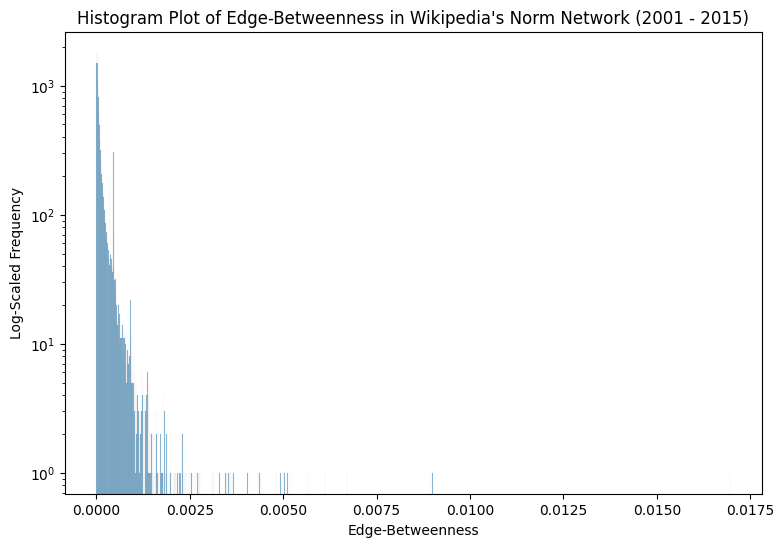

In [ ]:
plt.figure(figsize=(9,6))
plt.title("Histogram Plot of Edge-Betweenness in Wikipedia's Norm Network (2001 - 2015)")
plt.xlabel("Edge-Betweenness")
plt.yscale("log")
plt.ylabel("Log-Scaled Frequency")
sns.histplot(betweenness_values.values(), legend=False)
plt.show()

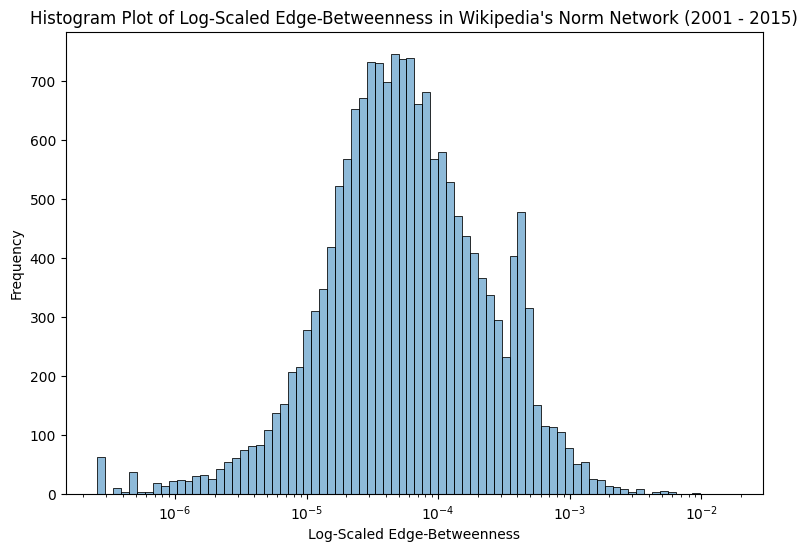

In [ ]:
plt.figure(figsize=(9,6))
plt.title("Histogram Plot of Log-Scaled Edge-Betweenness in Wikipedia's Norm Network (2001 - 2015)")
plt.xlabel("Log-Scaled Edge-Betweenness")
plt.xscale("log")
plt.ylabel("Frequency")
sns.histplot(betweenness_values.values(), legend=False)
plt.show()

In [ ]:
# Finding the most important norm-to-norm connections
sorted_betweenness = {edge: centrality for edge, centrality in sorted(betweenness_values.items(), key=lambda item : item[1])[::-1]}

In [ ]:
print("Top 20 edges by betweenness centrality:\n")
rank = 1
print(f"{"":20} {"Source":65s} {"Target":35s} Betweenness\n")
print(f"{"":20} {"------":65s} {"------":35s} -----------\n")
for (source, target, _), betweenness in list(sorted_betweenness.items())[:20]:
  print(f"  {rank:2}. {id_to_name[source]:<60s} {id_to_name[target]:<50s} {betweenness:}")
  rank += 1

Top 20 edges by betweenness centrality:

                     Source                                                            Target                              Betweenness

                     ------                                                            ------                              -----------

   1. User_categories                                              WikiFauna                                          0.016966080997027077
   2. Article_titles                                               Proposed_naming_conventions_and_guidelines         0.008989889017652576
   3. Policies_and_guidelines                                      Perennial_proposals                                0.008937441399281001
   4. Categorization                                               User_categories                                    0.006701353157455426
   5. Policies_and_guidelines                                      Principles                                         0.00612135295

In [ ]:
print("Communities of top 20 edges by betweenness centrality:\n")
rank = 1
print(f"{"":10} {"Source":30s} {"Target":30s} Betweenness\n")
print(f"{"":10} {"------":30s} {"------":30s} -----------\n")
for (source, target, _), betweenness in list(sorted_betweenness.items())[:20]:
  print(f"  {rank:2}. {community_labels[id_to_comm[source]]:<30s} {community_labels[id_to_comm[target]]:<30s} {betweenness:}")
  rank += 1

Communities of top 20 edges by betweenness centrality:

           Source                         Target                         Betweenness

           ------                         ------                         -----------

   1. Formatting Articles            Wiki-larping                   0.016966080997027077
   2. Formatting Articles            Formatting Articles            0.008989889017652576
   3. Collaboration                  Administrators                 0.008937441399281001
   4. Formatting Articles            Formatting Articles            0.006701353157455426
   5. Collaboration                  Collaboration                  0.006121352950729925
   6. Collaboration                  Collaboration                  0.005720939402570051
   7. Formatting Articles            Page Templates                 0.005642529215418606
   8. Article Quality                Article Quality                0.00519857316321553
   9. Administrators                 Formatting Articles     

In [ ]:
# Count types of norm-to-norm edges
edge_type_count = defaultdict(int)
for (source, target, _), _ in list(sorted_betweenness.items()):
  edge_type_count[(community_labels[id_to_comm[source]], community_labels[id_to_comm[target]])] += 1
edge_type_count = {(source, target): count for (source, target), count in sorted(edge_type_count.items(), key=lambda item : item[1])[::-1]}

print("Norm-to-Norm edge types:\n")

print(f"{"Source":30s} {"Target":30s} {"Count":10s} Fraction\n")
print(f"{"------":30s} {"------":30s} {"-----":10s} --------\n")
for (source, target), count in list(edge_type_count.items()):
    print(f"{source:<30s} {target:<30s} {count:<10} {count / sum(edge_type_count.values()):.6f}")

Norm-to-Norm edge types:

Source                         Target                         Count      Fraction

------                         ------                         -----      --------

Article Quality                Article Quality                3404       0.197505
Collaboration                  Collaboration                  2915       0.169133
Administrators                 Administrators                 1563       0.090688
Formatting Articles            Formatting Articles            1126       0.065332
Content Policies               Content Policies               718        0.041659
Collaboration                  Article Quality                718        0.041659
Collaboration                  Administrators                 600        0.034813
Administrators                 Collaboration                  593        0.034407
Article Quality                Collaboration                  566        0.032840
Formatting Articles            Article Quality                410     

### Girvan-Newman Partitioning

The NetworkX implementation of Girvan-Newman does not work for directed graphs, since it converts the graph into an undirected graph (see [documentation and source code](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.centrality.girvan_newman.html)).

We implement a custom directed version below.

#### Directed Case



*   We see that the giant SCC has a distinct sub-community (i.e. WikiLarping communities) that is strongly connected itself.
*   After the first partitioning of the SCC, it becomes harder to partition it again (takes more iterations). Also, the resulting communities don't have a new "medium sized" community. Rather, there are more fragments of the SCC.
* At the third paritioning, we have take roughly 20 steps before we split a single node from the giant SCC. This implies that the SCC from here on out is very connected.


In [ ]:
# Implementation inspired by NetworkX girvan_newman() source code
def girvan_newman_step(G):
  centralities = {edge: centrality for edge, centrality in sorted(nx.edge_betweenness_centrality(G, k=len(G)).items(), key=lambda item : item[1])[::-1]}
  edges_to_remove = []
  max_centrality = list(centralities.items())[0][1]
  for (source, target, _), centrality in list(centralities.items()):
    if centrality == max_centrality:
      edges_to_remove.append((source, target))

  g = G.copy()
  old_components = tuple(nx.strongly_connected_components(g))

  for edge in edges_to_remove:
    g.remove_edge(*edge)

  new_components = tuple(nx.strongly_connected_components(g))

  return old_components, new_components, edges_to_remove

Step 1

In [ ]:
g = G.copy()
all_removed_edges = []
steps = 0
while True:
  steps += 1
  old_components, new_components, edges_removed = girvan_newman_step(g)

  # Replicate the edge removal in actual graph to input into next step
  for edge in edges_removed:
    g.remove_edge(*edge)

  all_removed_edges.append(edges_removed)

  if len(new_components) > len(old_components):
    print("Components:", sorted(new_components))
    print("Edges Removed:", all_removed_edges)
    print("Steps until a component is partitioned:", steps)
    print()
    break

for step in all_removed_edges:
  for edge in step:
    source, target = edge
    print(f"{id_to_name[source]} ({community_labels[id_to_comm[source]]})", "|", f"{id_to_name[target]} ({community_labels[id_to_comm[target]]})")

Components: [{93}, {9}, {392}, {848}, {650, 1067}, {466}, {191}, {904}, {702}, {365}, {1378}, {940}, {942}, {671}, {875}, {1011}, {74}, {1631}, {504, 1598, 1599}, {1597}, {1077}, {97}, {329}, {1604}, {918}, {991}, {1706}, {597}, {1634}, {1081}, {1798}, {937}, {1552}, {594}, {902}, {78}, {315}, {1486}, {242}, {1672, 1865}, {1844}, {1680}, {1656}, {1603}, {762}, {952}, {953}, {1370}, {1630}, {963}, {1965}, {1310}, {1298}, {598}, {731}, {1035}, {1230}, {1258}, {960}, {965}, {794}, {900}, {560}, {832}, {1198}, {123}, {1414}, {1481}, {1429}, {401}, {0, 1, 2, 4, 6, 7, 10, 11, 12, 13, 14, 16, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 50, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 68, 71, 75, 76, 79, 80, 81, 83, 84, 86, 87, 89, 90, 91, 92, 94, 95, 96, 98, 99, 102, 103, 105, 107, 110, 111, 112, 115, 116, 117, 118, 120, 124, 126, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 141, 143, 144, 145, 146, 147, 148, 149, 1

In [ ]:
sorted_components = sorted(old_components, key=len)[::-1]

for component in sorted_components[:4]:
    print(f"Size of Component = {len(component)}\n")
    for node in list(component)[:20]:
        print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
    print("\n")

Size of Component = 1345

In_popular_culture_content                    Article Quality
Murder_of_articles                            Article Quality
Note_that_is_unnecessary                  Formatting Articles
100,000_feature-quality_articles               Content Policies
AKA_names                                      Page Templates
ANI_advice                                      Collaboration
A_navbox_on_every_page                    Formatting Articles
A_nice_cup_of_tea_and_a_sit_down                  Collaboration
A_note_regarding_BRD                            Collaboration
A_primer_for_newcomers                       Content Policies
A_researcher's_guide_to_discussion_pages                 Administrators
About                                        Content Policies
About_Valid_Routine_Calculations                Article Quality
About_page_view_statistics                Formatting Articles
About_the_Sandbox                              Administrators
Abundance_and_redundancy    

In [ ]:
sorted_components = sorted(new_components, key=len)[::-1]

for component in sorted_components[:4]:
    print(f"Size of Component = {len(component)}\n")
    for node in list(component)[:20]:
        print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
    print("\n")

Size of Component = 1303

In_popular_culture_content                    Article Quality
Murder_of_articles                            Article Quality
Note_that_is_unnecessary                  Formatting Articles
100,000_feature-quality_articles               Content Policies
AKA_names                                      Page Templates
ANI_advice                                      Collaboration
A_navbox_on_every_page                    Formatting Articles
A_nice_cup_of_tea_and_a_sit_down                  Collaboration
A_note_regarding_BRD                            Collaboration
A_primer_for_newcomers                       Content Policies
A_researcher's_guide_to_discussion_pages                 Administrators
About                                        Content Policies
About_Valid_Routine_Calculations                Article Quality
About_page_view_statistics                Formatting Articles
About_the_Sandbox                              Administrators
Abundance_and_redundancy    

Step 2

In [ ]:
while True:
  steps += 1
  old_components, new_components, edges_removed = girvan_newman_step(g)

  # Replicate the edge removal in actual graph to input into next step
  for edge in edges_removed:
    g.remove_edge(*edge)

  all_removed_edges.append(edges_removed)

  if len(new_components) > len(old_components):
    print("Components:", sorted(new_components))
    print("Edges Removed:", all_removed_edges)
    print("Steps until a component is partitioned:", steps)
    print()
    break

for step in all_removed_edges:
  for edge in step:
    source, target = edge
    print(f"{id_to_name[source]} ({community_labels[id_to_comm[source]]})", "|", f"{id_to_name[target]} ({community_labels[id_to_comm[target]]})")

Components: [{93}, {9}, {392}, {848}, {650, 1067}, {466}, {191}, {904}, {702}, {365}, {504, 1598, 1599}, {1597}, {671}, {875}, {1011}, {74}, {1631}, {1077}, {1486}, {1706}, {329}, {1604}, {97}, {597}, {1634}, {78}, {1081}, {1798}, {991}, {594}, {902}, {937}, {1552}, {1844}, {1680}, {315}, {242}, {1672, 1865}, {918}, {1656}, {1603}, {762}, {1370}, {1630}, {963}, {1965}, {1310}, {1298}, {598}, {731}, {1035}, {1230}, {1258}, {1378}, {960}, {965}, {794}, {900}, {560}, {832}, {1198}, {123}, {1414}, {1481}, {1429}, {401}, {0, 1, 2, 4, 6, 7, 10, 11, 12, 13, 14, 16, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 50, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 68, 71, 75, 76, 79, 80, 81, 83, 84, 86, 87, 89, 90, 91, 92, 94, 95, 96, 98, 99, 102, 103, 105, 107, 110, 111, 112, 115, 116, 117, 118, 120, 124, 126, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 141, 143, 144, 145, 146, 147, 148, 149, 150, 152, 153, 154, 155, 156,

In [ ]:
sorted_components = sorted(old_components, key=len)[::-1]

for component in sorted_components[:4]:
    print(f"Size of Component = {len(component)}\n")
    for node in list(component)[:20]:
        print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
    print("\n")

Size of Component = 1303

In_popular_culture_content                    Article Quality
Murder_of_articles                            Article Quality
Note_that_is_unnecessary                  Formatting Articles
100,000_feature-quality_articles               Content Policies
AKA_names                                      Page Templates
ANI_advice                                      Collaboration
A_navbox_on_every_page                    Formatting Articles
A_nice_cup_of_tea_and_a_sit_down                  Collaboration
A_note_regarding_BRD                            Collaboration
A_primer_for_newcomers                       Content Policies
A_researcher's_guide_to_discussion_pages                 Administrators
About                                        Content Policies
About_Valid_Routine_Calculations                Article Quality
About_page_view_statistics                Formatting Articles
About_the_Sandbox                              Administrators
Abundance_and_redundancy    

In [ ]:
sorted_components = sorted(new_components, key=len)[::-1]

for component in sorted_components[:4]:
    print(f"Size of Component = {len(component)}\n")
    for node in list(component)[:20]:
        print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
    print("\n")

Size of Component = 1290

In_popular_culture_content                    Article Quality
Murder_of_articles                            Article Quality
Note_that_is_unnecessary                  Formatting Articles
100,000_feature-quality_articles               Content Policies
AKA_names                                      Page Templates
ANI_advice                                      Collaboration
A_navbox_on_every_page                    Formatting Articles
A_nice_cup_of_tea_and_a_sit_down                  Collaboration
A_note_regarding_BRD                            Collaboration
A_primer_for_newcomers                       Content Policies
A_researcher's_guide_to_discussion_pages                 Administrators
About                                        Content Policies
About_Valid_Routine_Calculations                Article Quality
About_page_view_statistics                Formatting Articles
About_the_Sandbox                              Administrators
Abundance_and_redundancy    

Step 3

In [ ]:
while True:
  steps += 1
  old_components, new_components, edges_removed = girvan_newman_step(g)

  # Replicate the edge removal in actual graph to input into next step
  for edge in edges_removed:
    g.remove_edge(*edge)

  all_removed_edges.append(edges_removed)

  if len(new_components) > len(old_components):
    print("Components:", sorted(new_components))
    print("Edges Removed:", all_removed_edges)
    print("Steps until a component is partitioned:", steps)
    print()
    break

for step in all_removed_edges:
  for edge in step:
    source, target = edge
    print(f"{id_to_name[source]} ({community_labels[id_to_comm[source]]})", "|", f"{id_to_name[target]} ({community_labels[id_to_comm[target]]})")

sorted_components = sorted(old_components, key=len)[::-1]

for component in sorted_components[:4]:
    print(f"Size of Component = {len(component)}\n")
    for node in list(component)[:20]:
        print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
    print("\n")

print("-----------------------------------------------------------------------------------------")

sorted_components = sorted(new_components, key=len)[::-1]

for component in sorted_components[:4]:
    print(f"Size of Component = {len(component)}\n")
    for node in list(component)[:20]:
        print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
    print("\n")

Components: [{93}, {848}, {650, 1067}, {191}, {1631}, {904}, {963}, {671}, {875}, {504, 1598, 1599}, {1597}, {937}, {1552}, {702}, {365}, {9}, {1486}, {315}, {1011}, {97}, {1706}, {74}, {1081}, {1798}, {597}, {1634}, {78}, {594}, {902}, {1844}, {329}, {1680}, {1604}, {242}, {1672, 1865}, {1481}, {1298}, {1310}, {1965}, {918}, {731}, {1077}, {1603}, {762}, {1370}, {1630}, {466}, {1656}, {1378}, {960}, {965}, {991}, {598}, {1035}, {1230}, {1258}, {794}, {392}, {1198}, {123}, {832}, {560}, {1414}, {1429}, {900}, {401}, {0, 1, 2, 4, 6, 7, 10, 11, 12, 13, 14, 16, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 50, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 68, 71, 75, 76, 79, 80, 81, 83, 84, 86, 87, 89, 90, 91, 92, 94, 95, 96, 98, 99, 102, 103, 105, 107, 110, 111, 112, 115, 116, 117, 118, 120, 124, 126, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 141, 143, 144, 145, 146, 147, 148, 149, 150, 152, 153, 154, 155, 156,

#### Undirected Case

*   We observe the same type of behavior in the undirected case, with a sub-community of WikiLarping breaking off of the largest community. However, it is much harder to disconnected the largest connected component.


In [ ]:
# k controls the number of partitioning steps we make (e.g. 1 = until 1 community split, 2 = 2 until communities split)
k = 2
comp = nx.community.girvan_newman(G)
for communities in itertools.islice(comp, k):
    sorted_components = sorted(communities, key=len)[::-1]

    for component in sorted_components[:4]:
        print(f"Size of Component = {len(component)}\n")
        for node in list(component)[:20]:
            print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
        print("\n")
    print("-----------------------------------------------------------------------------------------")

Size of Component = 1869

In_popular_culture_content                    Article Quality
Murder_of_articles                            Article Quality
Note_that_is_unnecessary                  Formatting Articles
1.5_sources                                   Article Quality
100,000_feature-quality_articles               Content Policies
99_Bottles_of_Beer_test                       Article Quality
AKA_names                                      Page Templates
ANI_advice                                      Collaboration
A_Side_of_Chips                                  Wiki-larping
A_navbox_on_every_page                    Formatting Articles
A_nice_cup_of_tea_and_a_sit_down                  Collaboration
A_note_regarding_BRD                            Collaboration
A_primer_for_newcomers                       Content Policies
A_researcher's_guide_to_discussion_pages                 Administrators
A_warning_to_concert_organizers               Content Policies
About                        

## 2001 - 2007

### Compute and Visualize Edge Betweenness Centralities

In [ ]:
betweenness_values_2007 = nx.edge_betweenness_centrality(G_2007, k=len(G_2007))

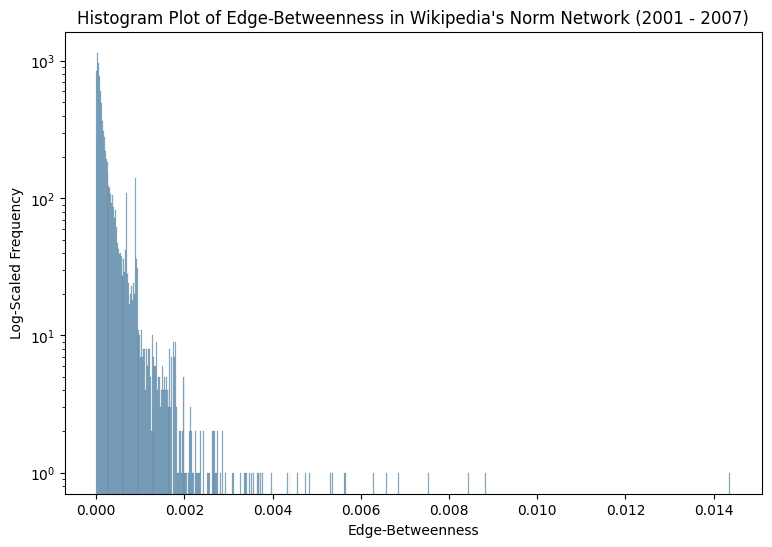

In [ ]:
plt.figure(figsize=(9,6))
plt.title("Histogram Plot of Edge-Betweenness in Wikipedia's Norm Network (2001 - 2007)")
plt.xlabel("Edge-Betweenness")
plt.yscale("log")
plt.ylabel("Log-Scaled Frequency")
sns.histplot(betweenness_values_2007.values(), legend=False)
plt.show()

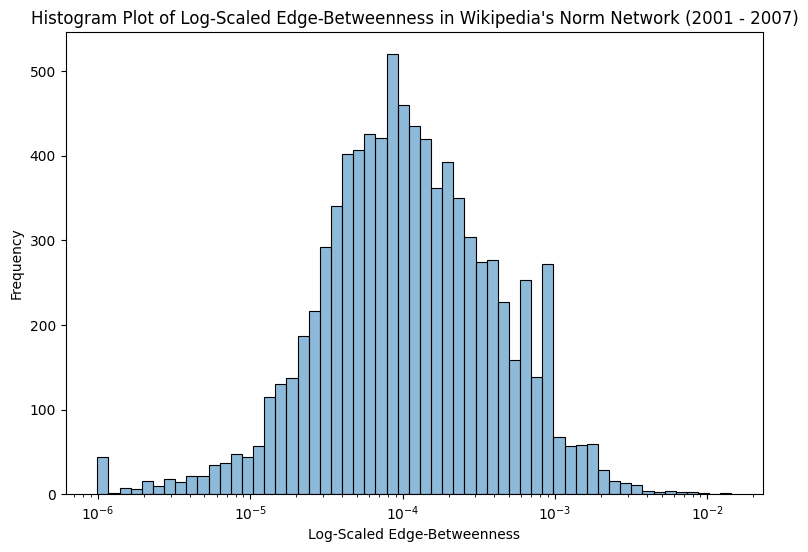

In [ ]:
plt.figure(figsize=(9,6))
plt.title("Histogram Plot of Log-Scaled Edge-Betweenness in Wikipedia's Norm Network (2001 - 2007)")
plt.xlabel("Log-Scaled Edge-Betweenness")
plt.xscale("log")
plt.ylabel("Frequency")
sns.histplot(betweenness_values_2007.values(), legend=False)
plt.show()

In [ ]:
# Finding the most important norm-to-norm connections
sorted_betweenness_2007 = {edge: centrality for edge, centrality in sorted(betweenness_values_2007.items(), key=lambda item : item[1])[::-1]}

In [ ]:
print("Top 20 edges by betweenness centrality:\n")
rank = 1
print(f"{"":20} {"Source":65s} {"Target":35s} Betweenness\n")
print(f"{"":20} {"------":65s} {"------":35s} -----------\n")
for (source, target, _), betweenness in list(sorted_betweenness_2007.items())[:20]:
  print(f"  {rank:2}. {id_to_name[source]:<60s} {id_to_name[target]:<50s} {betweenness:}")
  rank += 1

Top 20 edges by betweenness centrality:

                     Source                                                            Target                              Betweenness

                     ------                                                            ------                              -----------

   1. Policies_and_guidelines                                      Perennial_proposals                                0.014380169158532173
   2. Edit_warring                                                 Lamest_edit_wars                                   0.00880947012556613
   3. Arguments_to_avoid_in_deletion_discussions                   Silly_Things                                       0.008428659111353608
   4. Wikipedians                                                  Wikipediholic                                      0.007546225672882395
   5. Administrators                                               Requests_for_de-adminship                          0.006865008041

In [ ]:
community_labels = {1: "Article Quality",
                    2: "Collaboration",
                    3: "Administrators",
                    4: "Formatting Articles",
                    5: "Content Policies",
                    6: "Wiki-larping",
                    7: "Page Templates",
                    8: "Experts and Credentials",
                    9: "Humor",
                    10: "None",
                    -1: "None"}

print("Communities of top 20 edges by betweenness centrality:\n")
rank = 1
print(f"{"":10} {"Source":30s} {"Target":30s} Betweenness\n")
print(f"{"":10} {"------":30s} {"------":30s} -----------\n")
for (source, target, _), betweenness in list(sorted_betweenness_2007.items())[:20]:
  print(f"  {rank:2}. {community_labels[id_to_comm[source]]:<30s} {community_labels[id_to_comm[target]]:<30s} {betweenness:}")
  rank += 1

Communities of top 20 edges by betweenness centrality:

           Source                         Target                         Betweenness

           ------                         ------                         -----------

   1. Collaboration                  Administrators                 0.014380169158532173
   2. Collaboration                  Collaboration                  0.00880947012556613
   3. Article Quality                Humor                          0.008428659111353608
   4. Administrators                 Wiki-larping                   0.007546225672882395
   5. Administrators                 Administrators                 0.006865008041197503
   6. Administrators                 Collaboration                  0.006577190342577785
   7. Collaboration                  Content Policies               0.006291150064025568
   8. Formatting Articles            Article Quality                0.0056571268599778434
   9. Formatting Articles            Formatting Articles    

In [ ]:
# Count types of norm-to-norm edges
edge_type_count_2007 = defaultdict(int)
for (source, target, _), _ in list(sorted_betweenness_2007.items()):
  edge_type_count_2007[(community_labels[id_to_comm[source]], community_labels[id_to_comm[target]])] += 1
edge_type_count_2007 = {(source, target): count for (source, target), count in sorted(edge_type_count_2007.items(), key=lambda item : item[1])[::-1]}

print("Norm-to-Norm edge types:\n")

print(f"{"Source":30s} {"Target":30s} {"Count":10s} Fraction\n")
print(f"{"------":30s} {"------":30s} {"-----":10s} --------\n")
for (source, target), count in list(edge_type_count_2007.items()):
    print(f"{source:<30s} {target:<30s} {count:<10} {count / sum(edge_type_count_2007.values()):.6f}")

Norm-to-Norm edge types:

Source                         Target                         Count      Fraction

------                         ------                         -----      --------

Article Quality                Article Quality                1447       0.167807
Collaboration                  Collaboration                  1366       0.158414
Formatting Articles            Formatting Articles            764        0.088600
Administrators                 Administrators                 749        0.086861
Content Policies               Content Policies               464        0.053810
Collaboration                  Article Quality                388        0.044996
Administrators                 Collaboration                  329        0.038154
Collaboration                  Administrators                 301        0.034907
Formatting Articles            Article Quality                294        0.034095
Article Quality                Collaboration                  269     

### Girvan-Newman Partitioning

**Comparison to full timeline**

*   In both the directed and undirected cases, each community consists of administrative-type articles. Additionally, the edges removed consist of admin/policy/credential pages. This is in contrast with 2001-2015, which has Wikilarping as a dominant community.
*   In the directed case, the number of edges needed to be removed to partition the network does not increase as steps increase. However, we do observe that the giant SCC is highly connected as only fragments break off during partitioning, instead of medium/large communities. The same behavior occurs for the undirected case, where the giant component is very connected.


#### Directed Case

Step 1

In [ ]:
g_2007 = G_2007.copy()
all_removed_edges = []
steps = 0
while True:
  steps += 1
  old_components, new_components, edges_removed = girvan_newman_step(g_2007)

  # Replicate the edge removal in actual graph to input into next step
  for edge in edges_removed:
    g_2007.remove_edge(*edge)

  all_removed_edges.append(edges_removed)

  if len(new_components) > len(old_components):
    print("Components:", sorted(new_components))
    print("Edges Removed:", all_removed_edges)
    print("Steps until a component is partitioned:", steps)
    print()
    break

for step in all_removed_edges:
  for edge in step:
    source, target = edge
    print(f"{id_to_name[source]} ({community_labels[id_to_comm[source]]})", "|", f"{id_to_name[target]} ({community_labels[id_to_comm[target]]})")

Components: [{848}, {466}, {650, 1067}, {242}, {991}, {963}, {937}, {671}, {594}, {904}, {1081}, {1713}, {294}, {78}, {315}, {1486}, {1230}, {1258}, {1672, 1865}, {329}, {902}, {1798}, {560}, {1844}, {504, 1598, 1599}, {1656}, {1370}, {1298}, {1310}, {1011}, {758}, {1597}, {1216}, {312}, {900}, {763}, {392}, {0, 4, 11, 14, 16, 21, 22, 24, 25, 30, 39, 40, 42, 44, 45, 46, 47, 50, 54, 61, 64, 75, 79, 86, 91, 92, 94, 98, 99, 102, 103, 112, 115, 116, 117, 118, 126, 130, 131, 132, 133, 136, 137, 138, 139, 141, 145, 146, 148, 150, 152, 154, 157, 158, 159, 160, 165, 168, 175, 182, 183, 184, 188, 189, 190, 192, 194, 199, 201, 203, 207, 211, 212, 213, 218, 221, 222, 223, 226, 230, 231, 232, 236, 237, 241, 247, 250, 254, 256, 257, 259, 266, 267, 274, 276, 280, 281, 285, 286, 290, 295, 299, 304, 305, 311, 316, 317, 320, 323, 325, 327, 328, 335, 336, 337, 341, 342, 343, 344, 346, 349, 352, 356, 357, 359, 360, 361, 362, 364, 373, 379, 380, 382, 385, 386, 387, 389, 391, 396, 399, 409, 412, 416, 417, 

In [ ]:
# Old Components
sorted_components = sorted(old_components, key=len)[::-1]

for component in sorted_components[:4]:
    print(f"Size of Component = {len(component)}\n")
    for node in list(component)[:20]:
        print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
    print("\n")

Size of Component = 652

In_popular_culture_content                    Article Quality
100,000_feature-quality_articles               Content Policies
A_nice_cup_of_tea_and_a_sit_down                  Collaboration
A_researcher's_guide_to_discussion_pages                 Administrators
About                                        Content Policies
About_the_Sandbox                              Administrators
Abundance_and_redundancy                  Formatting Articles
Academic_studies_of_Wikipedia                Content Policies
Academic_use                                 Content Policies
Accuracy_dispute                                Collaboration
Admin_recall                                   Administrators
Administration                                 Administrators
Administrator_Code_of_Conduct                  Administrators
Administrator_recall                           Administrators
Administrators                                 Administrators
Administrators'_how-to_guide   

In [ ]:
# New Components
sorted_components = sorted(new_components, key=len)[::-1]

for component in sorted_components[:4]:
    print(f"Size of Component = {len(component)}\n")
    for node in list(component)[:20]:
        print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
    print("\n")

Size of Component = 651

In_popular_culture_content                    Article Quality
100,000_feature-quality_articles               Content Policies
A_nice_cup_of_tea_and_a_sit_down                  Collaboration
A_researcher's_guide_to_discussion_pages                 Administrators
About                                        Content Policies
About_the_Sandbox                              Administrators
Abundance_and_redundancy                  Formatting Articles
Academic_studies_of_Wikipedia                Content Policies
Academic_use                                 Content Policies
Accuracy_dispute                                Collaboration
Admin_recall                                   Administrators
Administration                                 Administrators
Administrator_Code_of_Conduct                  Administrators
Administrator_recall                           Administrators
Administrators                                 Administrators
Administrators'_how-to_guide   

Step 2

In [ ]:
while True:
  steps += 1
  old_components, new_components, edges_removed = girvan_newman_step(g_2007)

  # Replicate the edge removal in actual graph to input into next step
  for edge in edges_removed:
    g_2007.remove_edge(*edge)

  all_removed_edges.append(edges_removed)

  if len(new_components) > len(old_components):
    print("Components:", sorted(new_components))
    print("Edges Removed:", all_removed_edges)
    print("Steps until a component is partitioned:", steps)
    print()
    break

for step in all_removed_edges:
  for edge in step:
    source, target = edge
    print(f"{id_to_name[source]} ({community_labels[id_to_comm[source]]})", "|", f"{id_to_name[target]} ({community_labels[id_to_comm[target]]})")

sorted_components = sorted(old_components, key=len)[::-1]

for component in sorted_components[:4]:
    print(f"Size of Component = {len(component)}\n")
    for node in list(component)[:20]:
        print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
    print("\n")

print("-----------------------------------------------------------------------------------------")

sorted_components = sorted(new_components, key=len)[::-1]

for component in sorted_components[:4]:
    print(f"Size of Component = {len(component)}\n")
    for node in list(component)[:20]:
        print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
    print("\n")

Components: [{848}, {466}, {650, 1067}, {242}, {904}, {329}, {1713}, {294}, {671}, {594}, {937}, {315}, {1486}, {991}, {504, 1598, 1599}, {560}, {1230}, {1258}, {78}, {1370}, {1844}, {1672, 1865}, {1798}, {1310}, {1298}, {902}, {1081}, {1011}, {1656}, {758}, {963}, {1597}, {1216}, {312}, {763}, {392}, {900}, {0, 4, 11, 14, 16, 21, 22, 24, 25, 30, 39, 40, 42, 44, 45, 46, 47, 50, 54, 61, 64, 75, 79, 86, 91, 92, 94, 98, 99, 102, 103, 112, 115, 116, 117, 118, 126, 130, 131, 132, 133, 136, 137, 138, 139, 141, 145, 146, 148, 150, 152, 154, 157, 158, 159, 160, 165, 168, 175, 182, 183, 184, 188, 189, 190, 192, 194, 199, 201, 203, 207, 211, 212, 213, 218, 221, 222, 223, 226, 230, 231, 232, 236, 237, 241, 247, 250, 254, 256, 257, 259, 266, 267, 274, 276, 280, 281, 285, 286, 290, 295, 299, 304, 305, 311, 316, 317, 320, 323, 325, 327, 328, 335, 336, 337, 341, 342, 343, 344, 346, 349, 352, 356, 357, 359, 360, 361, 362, 364, 373, 379, 380, 382, 385, 386, 387, 389, 391, 396, 399, 409, 412, 416, 417, 

Step 3

In [ ]:
while True:
  steps += 1
  old_components, new_components, edges_removed = girvan_newman_step(g_2007)

  # Replicate the edge removal in actual graph to input into next step
  for edge in edges_removed:
    g_2007.remove_edge(*edge)

  all_removed_edges.append(edges_removed)

  if len(new_components) > len(old_components):
    print("Components:", sorted(new_components))
    print("Edges Removed:", all_removed_edges)
    print("Steps until a component is partitioned:", steps)
    print()
    break

for step in all_removed_edges:
  for edge in step:
    source, target = edge
    print(f"{id_to_name[source]} ({community_labels[id_to_comm[source]]})", "|", f"{id_to_name[target]} ({community_labels[id_to_comm[target]]})")

sorted_components = sorted(old_components, key=len)[::-1]

for component in sorted_components[:4]:
    print(f"Size of Component = {len(component)}\n")
    for node in list(component)[:20]:
        print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
    print("\n")

print("-----------------------------------------------------------------------------------------")

sorted_components = sorted(new_components, key=len)[::-1]

for component in sorted_components[:4]:
    print(f"Size of Component = {len(component)}\n")
    for node in list(component)[:20]:
        print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
    print("\n")

Components: [{848}, {466}, {650, 1067}, {242}, {904}, {329}, {1713}, {294}, {671}, {594}, {937}, {315}, {1486}, {991}, {504, 1598, 1599}, {560}, {1230}, {1258}, {78}, {1370}, {1844}, {1672, 1865}, {1310}, {1298}, {902}, {1081}, {1011}, {1656}, {758}, {963}, {1597}, {1216}, {312}, {763}, {392}, {900}, {0, 4, 11, 14, 16, 21, 22, 24, 25, 30, 39, 40, 42, 44, 45, 46, 47, 50, 54, 61, 64, 75, 79, 86, 91, 92, 94, 98, 99, 102, 103, 112, 115, 116, 117, 118, 126, 130, 131, 132, 133, 136, 137, 138, 139, 141, 145, 146, 148, 150, 152, 154, 157, 158, 159, 160, 165, 168, 175, 182, 183, 184, 188, 189, 190, 192, 194, 199, 201, 203, 207, 211, 212, 213, 218, 221, 222, 223, 226, 230, 231, 232, 236, 237, 241, 247, 250, 254, 256, 257, 259, 266, 267, 274, 276, 280, 281, 285, 286, 290, 295, 299, 304, 305, 311, 316, 317, 320, 323, 325, 327, 328, 335, 336, 337, 341, 342, 343, 344, 346, 349, 352, 356, 357, 359, 360, 361, 362, 364, 373, 379, 380, 382, 385, 386, 387, 389, 391, 396, 399, 409, 412, 416, 417, 418, 419

#### Undirected Case

In [ ]:
# k controls the number of partitioning steps we make (e.g. 1 = until 1 community split, 2 = 2 until communities split)
k = 2
comp = nx.community.girvan_newman(G_2007)
for communities in itertools.islice(comp, k):
    sorted_components = sorted(communities, key=len)[::-1]

    for component in sorted_components[:4]:
        print(f"Size of Component = {len(component)}\n")
        for node in list(component)[:20]:
            print(f"{id_to_name[node]:<30s} {community_labels[id_to_comm[node]]:>30s}")
        print("\n")
    print("-----------------------------------------------------------------------------------------")

Size of Component = 933

In_popular_culture_content                    Article Quality
100,000_feature-quality_articles               Content Policies
A_nice_cup_of_tea_and_a_sit_down                  Collaboration
A_researcher's_guide_to_discussion_pages                 Administrators
About                                        Content Policies
About_the_Sandbox                              Administrators
Abundance_and_redundancy                  Formatting Articles
Academic_studies_of_Wikipedia                Content Policies
Academic_use                                 Content Policies
Accountability                                  Collaboration
Accuracy_dispute                                Collaboration
Added_or_removed_characters                    Administrators
Adjectives_in_your_recommendations                  Collaboration
Admin_buddies                                    Wiki-larping
Admin_recall                                   Administrators
Administration             